In [1]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
 
import sys
sys.path.insert(1, '../src')

from data_loader import cleaned_data
from data_processing import pad_data
import ast

In [2]:
data = cleaned_data()
padded_data = pad_data(data)
print(padded_data.shape)

100%|██████████| 21799/21799 [01:14<00:00, 294.42it/s]


(21799, 1100, 12)


In [3]:
# filepath = '../data/processed/cleaned_data.csv'
# d = np.array(data)
# pd.DataFrame(d.reshape(d.shape[0], -1)).to_csv(filepath, index=False)

In [4]:
progress = tqdm.tqdm(total=len(padded_data), desc="extracting peaks")

for i in range(len(padded_data)):
        for j in range(len(padded_data[0][0])):
                _, rpeaks = nk.ecg_peaks(padded_data[i][:,j], sampling_rate=100)
                
                if len(rpeaks["ECG_R_Peaks"]) < 4:
                        _, rpeaks = nk.ecg_peaks(padded_data[i][:,j], sampling_rate=100, method="elgendi2010")
                        
                
                rpeaks["ECG_R_Peaks"] = rpeaks["ECG_R_Peaks"]-100
                try:
                        _, waves_peak = nk.ecg_delineate(data[i][:,j], rpeaks, sampling_rate=100)
                except:
                        print("failed at index: ", i, j)
                # if i == 19 and j == 5:
                #         print(rpeaks)
                #         plot = nk.events_plot(rpeaks["ECG_R_Peaks"],  data[i][:,j])
                #         raise
                #         # print(waves_peak)
        progress.update(1)


extracting peaks:   7%|▋         | 1598/21799 [26:37<5:49:06,  1.04s/it]

failed at index:  1598 5


extracting peaks:  33%|███▎      | 7138/21799 [7:58:57<5:20:52,  1.31s/it]      

failed at index:  7138 5


extracting peaks:  34%|███▍      | 7391/21799 [8:04:13<5:45:06,  1.44s/it]

...

extracting peaks:  60%|██████    | 13098/21799 [10:01:56<3:11:06,  1.32s/it]

failed at index:  13098 3


extracting peaks:  90%|████████▉ | 19539/21799 [12:17:57<46:30,  1.23s/it]  

failed at index:  19539 3


extracting peaks: 100%|██████████| 21799/21799 [13:07:10<00:00,  1.18s/it]  

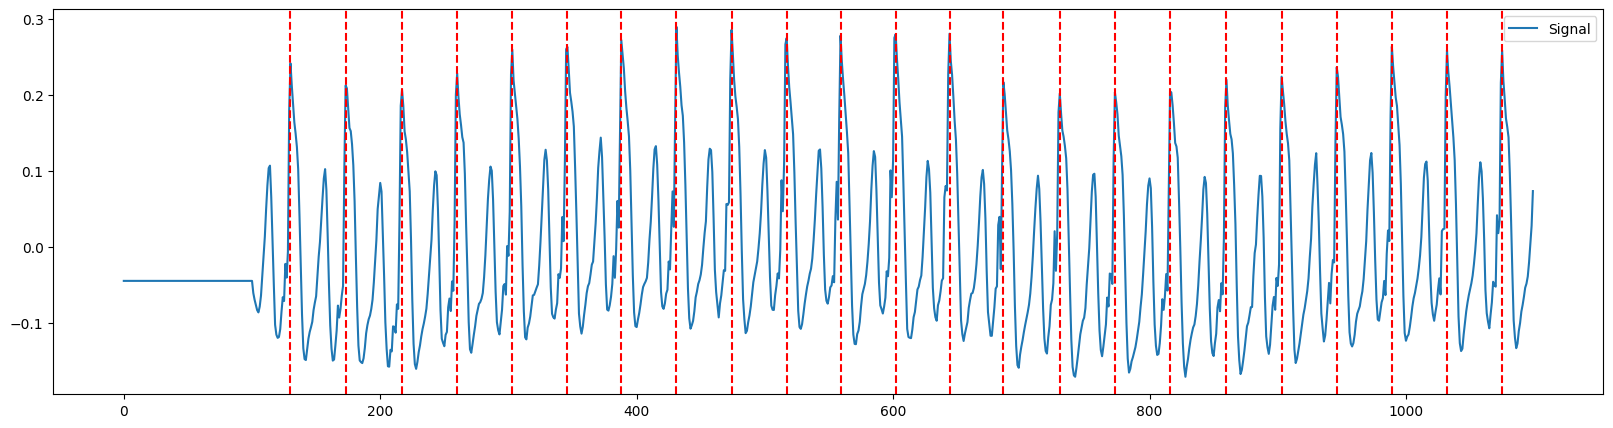

In [5]:
plt.rcParams['figure.figsize'] = [20, 5]
# plt.plot(padded_data[19][:,5])
# a = nk.ecg_clean(padded_data[410][:,4], sampling_rate=100)
a = nk.ecg_invert(padded_data[19][:,5], sampling_rate=100)
_, rpeaks = nk.ecg_peaks(a[0], sampling_rate=100, method="elgendi2010")
# print(rpeaks)
plot = nk.events_plot(rpeaks["ECG_R_Peaks"],  a[0])